In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [18]:
orders = pd.read_csv('olist_orders_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
translations = pd.read_csv('product_category_name_translation.csv')

print("Orders shape:", orders.shape)
print("Reviews shape:", reviews.shape)
print("Customers shape:", customers.shape)
print("Products shape:", products.shape)
print("Translations shape:", translations.shape)

Orders shape: (99441, 8)
Reviews shape: (99224, 7)
Customers shape: (99441, 5)
Products shape: (32951, 9)
Translations shape: (71, 2)


In [19]:
# Convert date columns to datetime
date_cols = [
    'order_purchase_timestamp',
    'order_estimated_delivery_date',
    'order_delivered_customer_date'
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# Step 1: Join reviews to orders on order_id
# Use drop_duplicates on reviews first to avoid row explosion
reviews_deduped = reviews.drop_duplicates(subset='order_id')
df = orders.merge(reviews_deduped[['order_id', 'review_score']], on='order_id', how='left')

# Step 2: Join customers to get state info
df = df.merge(customers[['customer_id', 'customer_state', 'customer_city']], on='customer_id', how='left')

print("Master dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Master dataset shape: (99441, 11)
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'review_score', 'customer_state', 'customer_city']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score,customer_state,customer_city
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,4.0,SP,sao paulo
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,4.0,BA,barreiras
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,5.0,GO,vianopolis
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,5.0,RN,sao goncalo do amarante
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,5.0,SP,santo andre


In [20]:
# Keep only DELIVERED orders for delay analysis
df_delivered = df[df['order_status'] == 'delivered'].copy()

# Drop rows where actual delivery date is missing
df_delivered = df_delivered.dropna(subset=['order_delivered_customer_date', 'order_estimated_delivery_date'])

# Calculate Days_Difference: positive = early, negative = late
df_delivered['Days_Difference'] = (
    df_delivered['order_estimated_delivery_date'] - df_delivered['order_delivered_customer_date']
).dt.days

# Classify delivery status
def classify_delivery(days):
    if days >= 0:
        return 'On Time'
    elif days >= -5:
        return 'Late'
    else:
        return 'Super Late'

df_delivered['delivery_status'] = df_delivered['Days_Difference'].apply(classify_delivery)

# Summary
print(df_delivered['delivery_status'].value_counts())
print(f"\nTotal delivered orders analysed: {len(df_delivered):,}")

delivery_status
On Time       88644
Super Late     4211
Late           3615
Name: count, dtype: int64

Total delivered orders analysed: 96,470


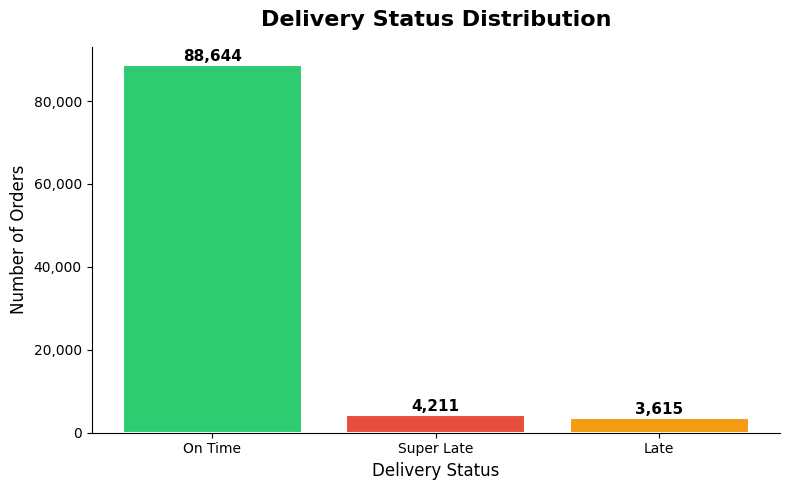

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))

status_counts = df_delivered['delivery_status'].value_counts()
colors = {'On Time': '#2ecc71', 'Late': '#f39c12', 'Super Late': '#e74c3c'}
bars = ax.bar(status_counts.index, status_counts.values,
              color=[colors[s] for s in status_counts.index], edgecolor='white', linewidth=1.5)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{bar.get_height():,}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title('Delivery Status Distribution', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Delivery Status', fontsize=12)
ax.set_ylabel('Number of Orders', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('delivery_status.png', dpi=150, bbox_inches='tight')
plt.show()

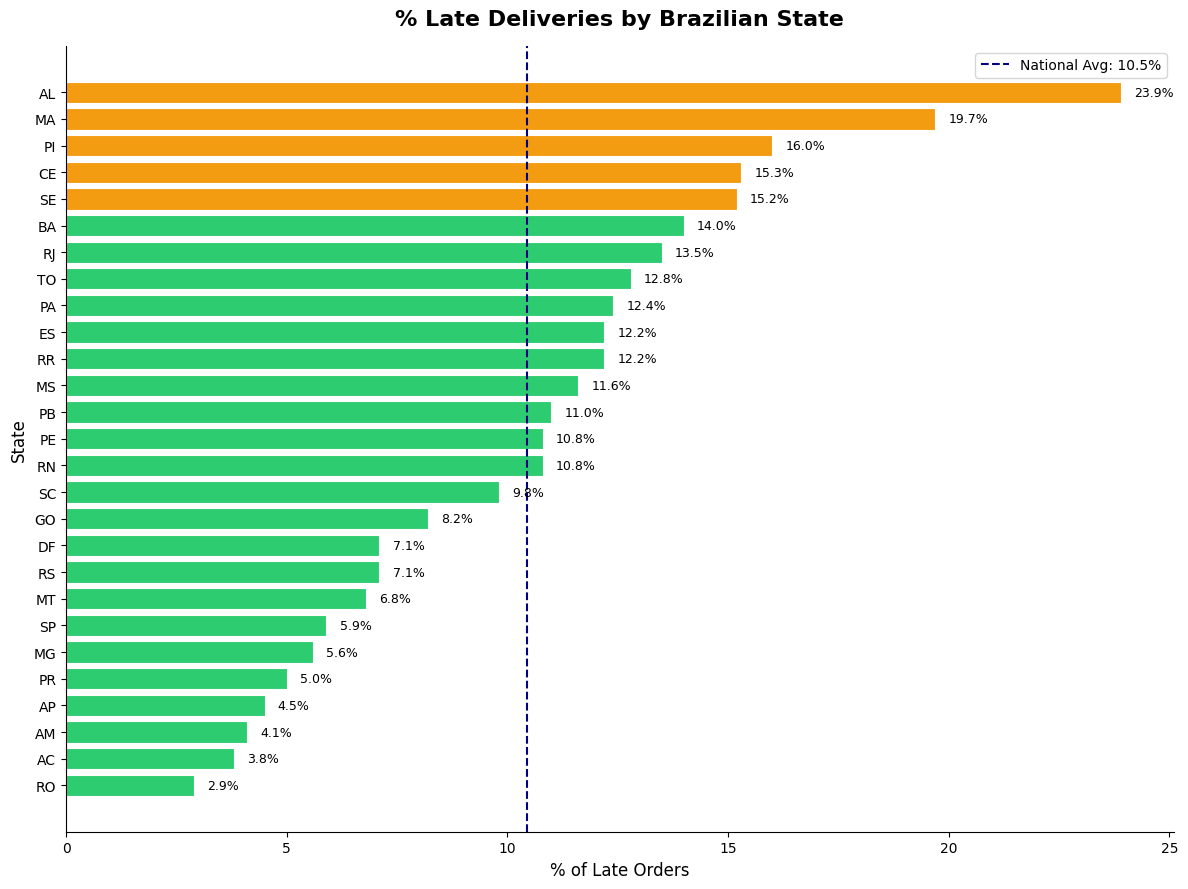


 Top 5 Worst States (% Late):
customer_state  pct_late  total_orders
            AL      23.9           397
            MA      19.7           717
            PI      16.0           476
            CE      15.3          1279
            SE      15.2           335


In [22]:
# Calculate % late orders per state
state_stats = df_delivered.groupby('customer_state').agg(
    total_orders=('order_id', 'count'),
    late_orders=('delivery_status', lambda x: (x != 'On Time').sum()),
    avg_delay_days=('Days_Difference', 'mean')
).reset_index()

state_stats['pct_late'] = (state_stats['late_orders'] / state_stats['total_orders'] * 100).round(1)
state_stats = state_stats.sort_values('pct_late', ascending=True)

# Bar chart of % late by state
fig, ax = plt.subplots(figsize=(12, 9))

bar_colors = ['#e74c3c' if p > 30 else '#f39c12' if p > 15 else '#2ecc71'
              for p in state_stats['pct_late']]

bars = ax.barh(state_stats['customer_state'], state_stats['pct_late'],
               color=bar_colors, edgecolor='white', linewidth=0.8)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.3, bar.get_y() + bar.get_height()/2,
            f'{w:.1f}%', va='center', fontsize=9)

ax.set_title('% Late Deliveries by Brazilian State', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('% of Late Orders', fontsize=12)
ax.set_ylabel('State', fontsize=12)
ax.axvline(x=state_stats['pct_late'].mean(), color='navy', linestyle='--', linewidth=1.5,
           label=f"National Avg: {state_stats['pct_late'].mean():.1f}%")
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('late_by_state.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top worst states
print("\n Top 5 Worst States (% Late):")
print(state_stats.nlargest(5, 'pct_late')[['customer_state', 'pct_late', 'total_orders']].to_string(index=False))

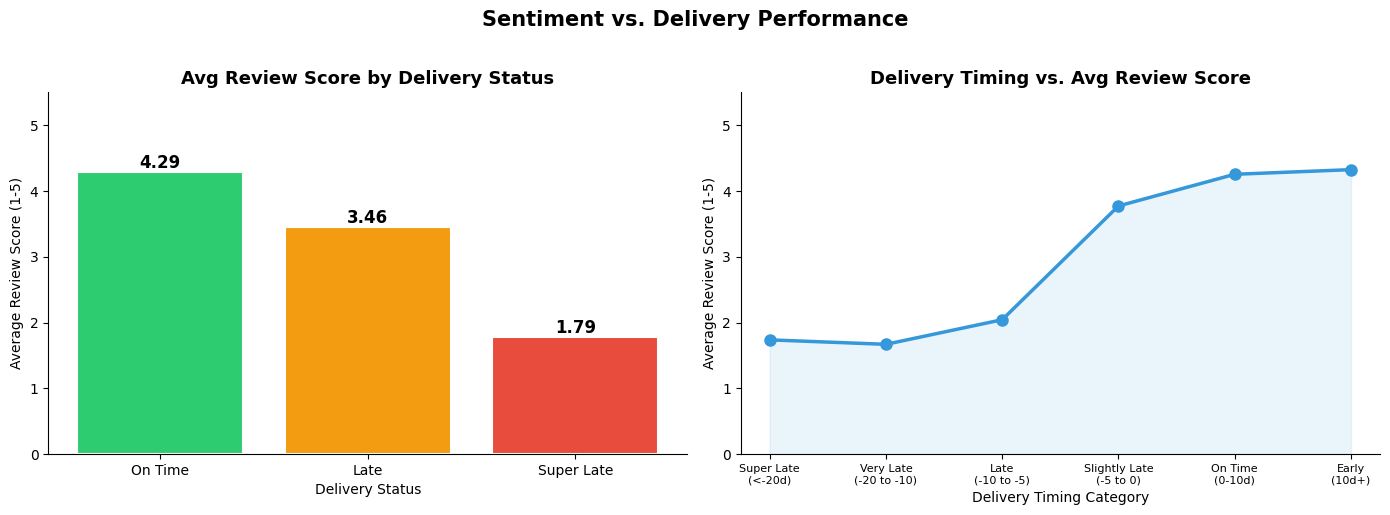

In [23]:
# Average review score by delivery status
avg_score = df_delivered.groupby('delivery_status')['review_score'].mean().reset_index()
avg_score.columns = ['delivery_status', 'avg_review_score']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Avg review score by status ---
order_cat = ['On Time', 'Late', 'Super Late']
avg_score['delivery_status'] = pd.Categorical(avg_score['delivery_status'], categories=order_cat, ordered=True)
avg_score = avg_score.sort_values('delivery_status')

colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = axes[0].bar(avg_score['delivery_status'], avg_score['avg_review_score'],
                   color=colors, edgecolor='white', linewidth=1.5)
for bar, score in zip(bars, avg_score['avg_review_score']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{score:.2f}', ha='center', fontweight='bold', fontsize=12)
axes[0].set_ylim(0, 5.5)
axes[0].set_title('Avg Review Score by Delivery Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Delivery Status')
axes[0].set_ylabel('Average Review Score (1-5)')
axes[0].spines[['top', 'right']].set_visible(False)

# --- Plot 2: Delay days vs avg review score (binned) ---
df_delivered['delay_bin'] = pd.cut(df_delivered['Days_Difference'],
                                    bins=[-999, -20, -10, -5, 0, 10, 999],
                                    labels=['Super Late\n(<-20d)', 'Very Late\n(-20 to -10)',
                                            'Late\n(-10 to -5)', 'Slightly Late\n(-5 to 0)',
                                            'On Time\n(0-10d)', 'Early\n(10d+)'])

bin_scores = df_delivered.groupby('delay_bin', observed=True)['review_score'].mean().reset_index()

axes[1].plot(bin_scores['delay_bin'].astype(str), bin_scores['review_score'],
             marker='o', color='#3498db', linewidth=2.5, markersize=8)
axes[1].fill_between(range(len(bin_scores)), bin_scores['review_score'],
                      alpha=0.1, color='#3498db')
axes[1].set_title('Delivery Timing vs. Avg Review Score', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Delivery Timing Category')
axes[1].set_ylabel('Average Review Score (1-5)')
axes[1].set_ylim(0, 5.5)
axes[1].set_xticks(range(len(bin_scores)))
axes[1].set_xticklabels(bin_scores['delay_bin'].astype(str), fontsize=8)
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Sentiment vs. Delivery Performance', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sentiment_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# Merge product category translations
products_translated = products.merge(translations, on='product_category_name', how='left')
products_translated['category_en'] = products_translated['product_category_name_english'].fillna(
    products_translated['product_category_name']
)

print("Sample translated categories:")
print(products_translated[['product_category_name', 'category_en']].drop_duplicates().head(10))

Sample translated categories:
   product_category_name          category_en
0             perfumaria            perfumery
1                  artes                  art
2          esporte_lazer       sports_leisure
3                  bebes                 baby
4  utilidades_domesticas           housewares
5  instrumentos_musicais  musical_instruments
6             cool_stuff           cool_stuff
7       moveis_decoracao      furniture_decor
8       eletrodomesticos      home_appliances
9             brinquedos                 toys


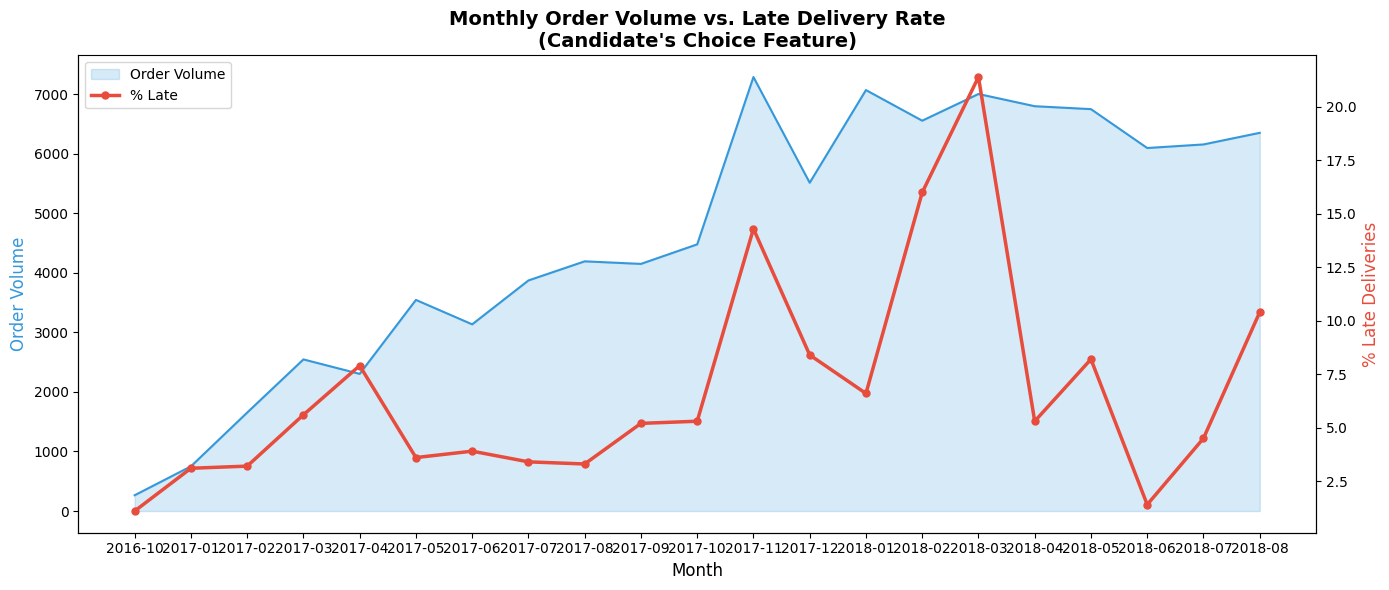

Business Justification: This chart shows whether the late delivery problem
is seasonal (fixable with temporary capacity) or structural (requires long-term investment).


In [25]:
# CANDIDATE'S CHOICE: Monthly Late Rate Trend
df_delivered['order_month'] = df_delivered['order_purchase_timestamp'].dt.to_period('M')

monthly = df_delivered.groupby('order_month').agg(
    total=('order_id', 'count'),
    late=('delivery_status', lambda x: (x != 'On Time').sum())
).reset_index()
monthly['pct_late'] = (monthly['late'] / monthly['total'] * 100).round(1)
monthly['order_month_str'] = monthly['order_month'].astype(str)

# Filter to months with enough data (> 100 orders)
monthly = monthly[monthly['total'] > 100]

fig, ax1 = plt.subplots(figsize=(14, 6))

ax2 = ax1.twinx()
ax1.fill_between(monthly['order_month_str'], monthly['total'],
                  alpha=0.2, color='#3498db', label='Order Volume')
ax1.plot(monthly['order_month_str'], monthly['total'],
          color='#3498db', linewidth=1.5)
ax2.plot(monthly['order_month_str'], monthly['pct_late'],
          color='#e74c3c', linewidth=2.5, marker='o', markersize=5, label='% Late')

ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Order Volume', color='#3498db', fontsize=12)
ax2.set_ylabel('% Late Deliveries', color='#e74c3c', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
ax1.set_title('Monthly Order Volume vs. Late Delivery Rate\n(Candidate\'s Choice Feature)',
               fontsize=14, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.spines[['top']].set_visible(False)
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print("Business Justification: This chart shows whether the late delivery problem")
print("is seasonal (fixable with temporary capacity) or structural (requires long-term investment).")

In [26]:
export_cols = [
    'order_id', 'order_purchase_timestamp', 'order_estimated_delivery_date',
    'order_delivered_customer_date', 'order_status', 'customer_state',
    'customer_city', 'review_score', 'Days_Difference', 'delivery_status'
]

df_delivered[export_cols].to_csv('veridi_master_data.csv', index=False)
print(f"Exported {len(df_delivered):,} rows to veridi_master_data.csv")

Exported 96,470 rows to veridi_master_data.csv
